# Базовое решение Задачи "Разработка нефтегазовых месторождений"

Набор данных содержит 442 о различных нефтегазовых месторождениях.
Тренировочный набор - 309 строк.
Тестовый набор - 133 строк.

Каждое месторождение обладает 19 параметрами:
1. Field name - название месторождения
2. Reservoir unit - юнит месторождения
3. Country - страна расположения
4. Region - регион расположения
5. Basin name - название бассейна пород
6. Tectonic regime - тектонический режим
7. Latitude - широта
8. Longitude - долгота
9. Operator company - название компании
10. Onshore or oﬀshore - на суше или нет
11. Hydrocarbon type (main) - тип углеводорода
12. Reservoir status (current) - статус месторождения
13. Structural setting - структурные свойства
14. Depth (top reservoir ft TVD) - глубина
15. Reservoir period - литологический период
16. Lithology (main) - литология
17. Thickness (gross average ft) - общая толщина
18. Thickness (net pay average ft) - эффективная толщина
19. Porosity (matrix average 20. Permeability (air average mD) – проницаемость

## Считывание данных

In [3]:
import opendatasets as od

# Загрузим датасет на прямую с kaggle
dataset_url = 'https://www.kaggle.com/competitions/classification-of-oil-and-gas/data'
# {"username":"adele1997","key":"b359174f8c6e8efc9d9869284646ee1e"}
# Upload Kaggle.json file to Colab… (Caution: Do not Share kaggle.json as contains API key of your Kaggle Account)

od.download(dataset_url)

Skipping, found downloaded files in "./classification-of-oil-and-gas" (use force=True to force download)


In [4]:
# иморитирование всех необходимых библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Считываем тренировочные данные
train = pd.read_csv("./classification-of-oil-and-gas/train_oil.csv")
test = pd.read_csv("./classification-of-oil-and-gas/oil_test.csv")
train_original = train.copy()

print(f"Train dataset shape: {train.shape}")
print(f"Test dataset shape: {test.shape}")

Train dataset shape: (309, 20)
Test dataset shape: (133, 19)


In [6]:
# Посмотрим как выглядят данные
train.head(6).T

,0,1,2,3,4,5
Field name,ZHIRNOV,LAGOA PARDA,ABQAIQ,MURCHISON,WEST PEMBINA,UCHKYR
Reservoir unit,MELEKESKIAN,LAGOA PARDA (URUCUTUCA),ARAB D,BRENT,NISKU (PEMBINA L POOL),XV-1
Country,RUSSIA,BRAZIL,SAUDI ARABIA,UK /NORWAY,CANADA,UZBEKISTAN
Region,FORMER SOVIET UNION,LATIN AMERICA,MIDDLE EAST,EUROPE,NORTH AMERICA,FORMER SOVIET UNION
Basin name,VOLGA-URAL,ESPIRITO SANTO,THE GULF,NORTH SEA NORTHERN,WESTERN CANADA,AMU DARYA
Tectonic regime,COMPRESSION/EVAPORITE,EXTENSION,COMPRESSION/EVAPORITE,EXTENSION,COMPRESSION,INVERSION/COMPRESSION/EXTENSION/EVAPORITE
Latitude,51.0,-19.6017,26.08,61.3833,53.2287,40.1494
Longitude,44.8042,-39.8332,49.81,1.75,-115.8008,62.9906
Operator company,NIZHNEVOLZHSKNET,PETROBRAS,SAUDI ARAMCO,CNR,NUMEROUS,SREDAZGAZPROM
Onshore/Offshore,ONSHORE,ONSHORE,ONSHORE,OFFSHORE,ONSHORE,ONSHORE


## Исследование и обработка данных

In [7]:
# процент дублей 
data = [train, test]
for df in data:
    print( (len(df) - len( df.drop_duplicates() )) * 100 / len(df) )

0.0
0.0


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setting              309 

In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      133 non-null    object 
 1   Reservoir unit                  133 non-null    object 
 2   Country                         120 non-null    object 
 3   Region                          117 non-null    object 
 4   Basin name                      125 non-null    object 
 5   Tectonic regime                 133 non-null    object 
 6   Latitude                        120 non-null    float64
 7   Longitude                       117 non-null    float64
 8   Operator company                133 non-null    object 
 9   Hydrocarbon type                133 non-null    object 
 10  Reservoir status                133 non-null    object 
 11  Structural setting              133 non-null    object 
 12  Depth                           133 

<Axes: >

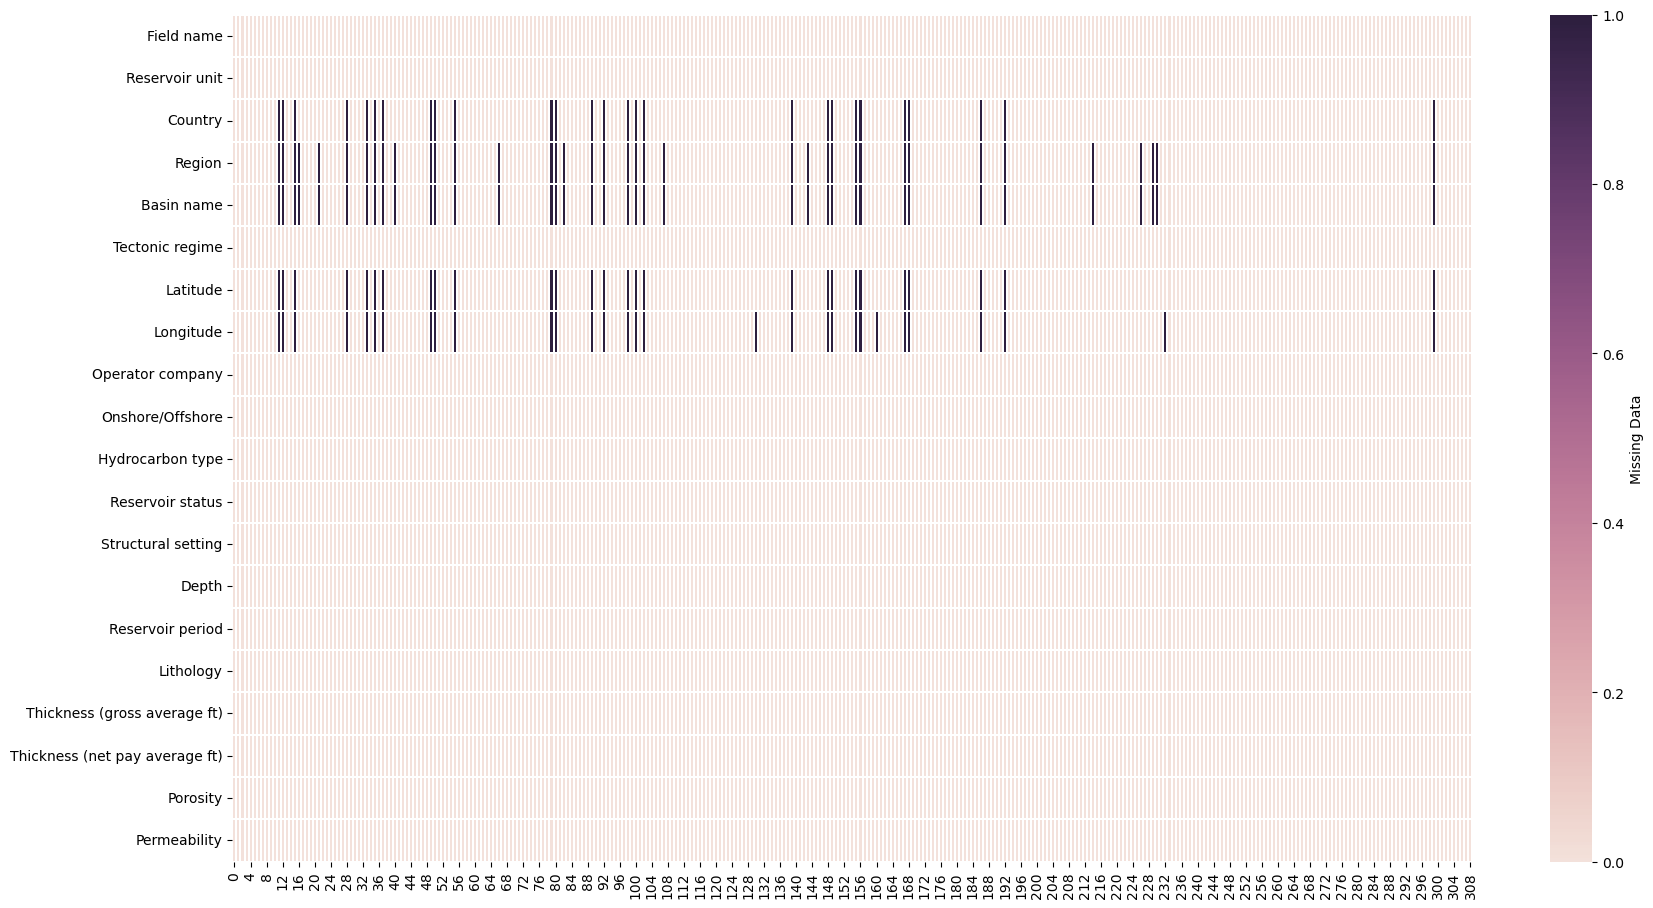

In [10]:
plt.figure(figsize=(20,11))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(train.isna().transpose(), cmap=cmap,
            cbar_kws={'label': 'Missing Data'}, linewidths=0.05)

# plt.savefig("visualizing_missing_data_with_heatmap_Seaborn_Python.png", dpi=500)

<Axes: >

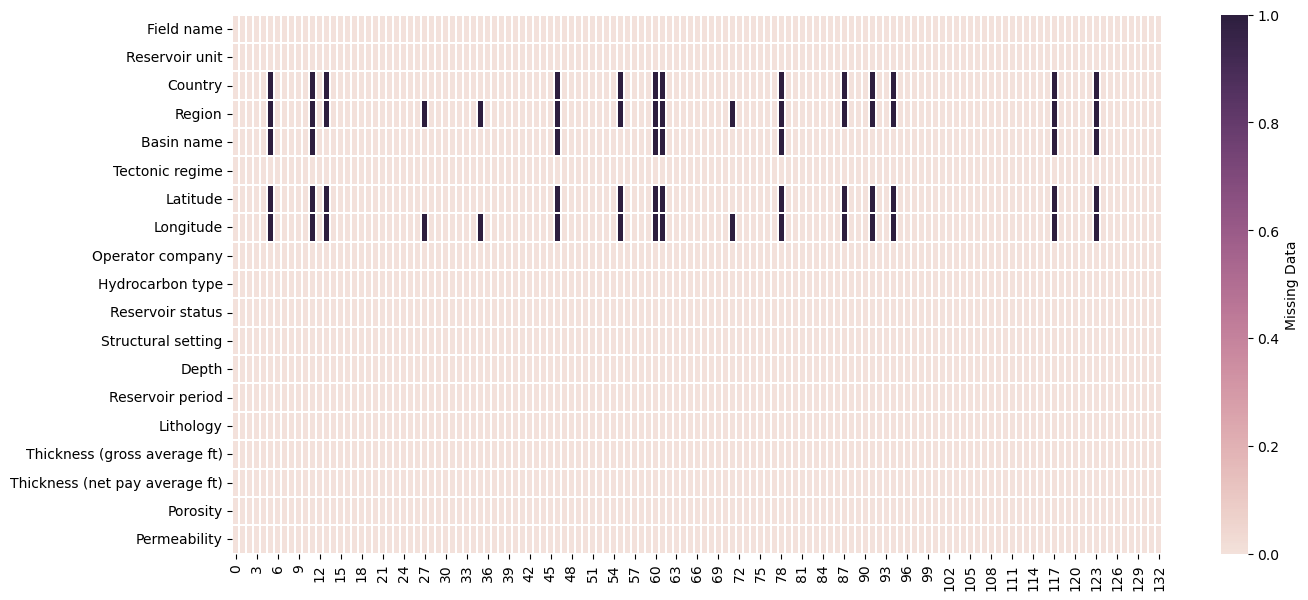

In [11]:
plt.figure(figsize=(15,7))

cmap = sns.cubehelix_palette(as_cmap=True, light=.9)

sns.heatmap(test.isna().transpose(), cmap=cmap,
            cbar_kws={'label': 'Missing Data'}, linewidths=0.05)

# plt.savefig("visualizing_missing_data_with_heatmap_Seaborn_Python.png", dpi=100)

In [12]:
df = train
df[df.isna().any(axis='columns')]

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
11,BADR EL DIN-2,BAHARIYA,NaN,NaN,NaN,EXTENSION,NaN,NaN,BAPETCO,ONSHORE,GAS-CONDENSATE,DECLINING PRODUCTION,RIFT,7546,CRETACEOUS,SANDSTONE,361.0,148.0,20.0,225.00
12,BRIDGER LAKE,DAKOTA SANDSTONE (LOWER MEMBER),NaN,NaN,NaN,COMPRESSION/EROSION,NaN,NaN,BTA OIL PRODUCERS,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,15460,CRETACEOUS,SANDSTONE,270.0,35.0,12.8,79.00
15,SCOTT,SGIATH-PIPER,NaN,NaN,NaN,EXTENSION/EVAPORITE,NaN,NaN,NEXEN,OFFSHORE,OIL,DECLINING PRODUCTION,RIFT,9940,JURASSIC,SANDSTONE,360.0,290.0,16.0,100.00
16,HEERA,BASSEIN (ZONE B),INDIA,NaN,NaN,EXTENSION,18.1720,72.3130,ONGC,OFFSHORE,OIL,DECLINING PRODUCTION,PASSIVE MARGIN,4542,PALEOGENE,LIMESTONE,230.0,82.0,12.0,0.80
21,GIDGEALPA,HUTTON,AUSTRALIA,NaN,NaN,INVERSION/COMPRESSION/EXTENSION,-28.0000,140.0000,SANTOS,ONSHORE,OIL,PLATEAU PRODUCTION,INTRACRATONIC,5392,JURASSIC,SANDSTONE,600.0,50.0,18.0,1000.00
28,ZAKUM,THAMAMA ZONE II,NaN,NaN,NaN,GRAVITY/EVAPORITE/COMPRESSION,NaN,NaN,ADMA /ZADCO,OFFSHORE,OIL,PLATEAU PRODUCTION,SALT/FORELAND,6940,CRETACEOUS,LIMESTONE,145.0,140.0,25.0,30.00
33,GASIKULE,UPPER GANCHAIGOU-LOWER YOUSHAS,NaN,NaN,NaN,COMPRESSION,NaN,NaN,PETROCHINA,ONSHORE,OIL,PLATEAU PRODUCTION,THRUST,4199,NEOGENE,SANDSTONE,3281.0,81.0,19.0,102.00
35,UZEN,UNITS XIII-XVIII,NaN,NaN,NaN,INVERSION/COMPRESSION/EXTENSION,NaN,NaN,MANGYSTAUMUNAIGAZ,ONSHORE,OIL,MATURE PRODUCTION,INVERSION/RIFT,3440,JURASSIC,SANDSTONE,920.0,436.0,21.0,235.00
37,ULA,ULA,NaN,NaN,NaN,INVERSION/COMPRESSION/EXTENSION/EVAPORITE,NaN,NaN,BP,OFFSHORE,OIL,MATURE PRODUCTION,SALT/INVERSION/RIFT,10744,JURASSIC,SANDSTONE,410.0,377.0,16.5,300.00
40,NORTH WARD-ESTES,YATES,USA,NaN,NaN,COMPRESSION,31.5777,-102.9918,WHITING OIL and GAS,ONSHORE,OIL,REJUVENATING,FORELAND,2600,PERMIAN,SILTSTONE,300.0,100.0,11.0,16.00


In [13]:
print(train.shape)
train = train.dropna()
print(train.shape)
# 309 - 268

(309, 20)
(268, 20)


### Обработка категориальных признаков

In [14]:
train.head().T

,0,1,2,3,4
Field name,ZHIRNOV,LAGOA PARDA,ABQAIQ,MURCHISON,WEST PEMBINA
Reservoir unit,MELEKESKIAN,LAGOA PARDA (URUCUTUCA),ARAB D,BRENT,NISKU (PEMBINA L POOL)
Country,RUSSIA,BRAZIL,SAUDI ARABIA,UK /NORWAY,CANADA
Region,FORMER SOVIET UNION,LATIN AMERICA,MIDDLE EAST,EUROPE,NORTH AMERICA
Basin name,VOLGA-URAL,ESPIRITO SANTO,THE GULF,NORTH SEA NORTHERN,WESTERN CANADA
Tectonic regime,COMPRESSION/EVAPORITE,EXTENSION,COMPRESSION/EVAPORITE,EXTENSION,COMPRESSION
Latitude,51.0,-19.6017,26.08,61.3833,53.2287
Longitude,44.8042,-39.8332,49.81,1.75,-115.8008
Operator company,NIZHNEVOLZHSKNET,PETROBRAS,SAUDI ARAMCO,CNR,NUMEROUS
Onshore/Offshore,ONSHORE,ONSHORE,ONSHORE,OFFSHORE,ONSHORE


In [15]:
train['Tectonic regime'].value_counts()

Tectonic regime
COMPRESSION                                                 57
EXTENSION                                                   26
COMPRESSION/EROSION                                         25
COMPRESSION/EVAPORITE                                       18
INVERSION/COMPRESSION/EXTENSION                             17
EXTENSION/EROSION                                           12
GRAVITY/EXTENSION/EVAPORITE                                 10
INVERSION/COMPRESSION/EXTENSION/EROSION                      7
GRAVITY/EXTENSION/EVAPORITE/SYNSEDIMENTATION                 7
COMPRESSION/EVAPORITE/EXTENSION/LINKED                       7
INVERSION/STRIKE-SLIP/TRANSPRESSION/EXTENSION/BASEMENT-I     5
COMPRESSION/EXTENSION/LINKED                                 4
GRAVITY/EVAPORITE/EXTENSION                                  4
INVERSION/COMPRESSION/EXTENSION/EVAPORITE                    4
GRAVITY/EVAPORITE/COMPRESSION                                4
COMPRESSION/EXTENSION/EVAPORITE        

In [16]:
train['Tectonic regime'].nunique()

54

In [17]:
# pd.get_dummies()
train['Tectonic regime'].str.get_dummies(sep='/').T

# Tectonic_regime_BASEMENT-I

,0,1,2,3,4,5,6,7,8,9,...,298,300,301,302,303,304,305,306,307,308
BASEMENT-I,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
COMPRESSION,1,0,1,0,1,1,1,0,1,1,...,1,0,1,1,1,1,1,1,1,1
DIAPIR,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EROSION,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
EVAPORITE,1,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
EXTENSION,0,1,0,1,0,1,0,1,0,0,...,1,0,1,0,0,0,1,0,0,0
GRAVITY,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
INVERSION,0,0,0,0,0,1,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
LINKED,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
REACTIVATION,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Как мы видим в колонке 'Tectonic regime' множество разных категорий, причем одному объекту может соответствовать несколько категорий сразу.

Встает вопрос как обработать такие признаки.

In [18]:
train['Structural setting'].value_counts()

Structural setting
FORELAND                      67
RIFT                          43
INTRACRATONIC                 27
THRUST                        14
PASSIVE MARGIN                12
SALT/FORELAND                 11
SALT/PASSIVE MARGIN            9
DELTA/PASSIVE MARGIN           7
INVERSION/RIFT                 7
INVERSION/BACKARC              6
SALT/INVERSION/RIFT            5
DELTA/SALT/PASSIVE MARGIN      5
THRUST/FORELAND                4
SUB-THRUST/FORELAND            4
RIFT/SALT                      4
BACKARC                        3
RIFT/INVERSION                 3
SUB-SALT/FORELAND              3
SUB-SALT/RIFT                  3
WRENCH                         3
THRUST/SUB-THRUST/FORELAND     2
FORELAND/THRUST                2
SALT/RIFT                      2
FORELAND/SALT                  2
SUB-THRUST                     2
WRENCH/DELTA                   2
SUB-SALT/INVERSION             2
WRENCH/INVERSION/BACKARC       1
SUB-SALT/PASSIVE MARGIN        1
WRENCH/PASSIVE MARGIN   

In [19]:
train['Basin name'].value_counts().head(50)

Basin name
WESTERN CANADA                      24
GULF OF MEXICO NORTHERN ONSHORE     19
NORTH SEA CENTRAL                   14
NORTH SEA NORTHERN                  12
WILLISTON                           10
PERMIAN                             10
BOHAI                                8
ANADARKO                             7
SIBERIAN WESTERN                     7
POWDER RIVER                         6
RUB AL KHALI                         6
THE GULF                             5
CAMBAY                               4
MID-NORWAY SHELF                     4
CASPIAN SOUTH                        4
EASTERN VENEZUELA                    4
GREATER GREEN RIVER                  4
PARIS                                4
GIPPSLAND                            4
SIBERIAN EASTERN                     4
JIUQUAN                              4
PARADOX                              3
BIG HORN                             3
AMU DARYA                            3
CASPIAN NORTH                        3
JEANNE D ARC  

In [20]:
train['Operator company'].value_counts()

Operator company
NUMEROUS                        26
CHEVRON                         15
PETROCHINA                      14
BP                               9
SHELL                            9
                                ..
EXXONMOBIL /SMNG                 1
OIL SEARCH LTD                   1
PANARCTIC OILS                   1
SAMUEL GARY                      1
MATRIX PRODUCTION AND OTHERS     1
Name: count, Length: 123, dtype: int64

In [21]:
train['Region'].value_counts()

Region
NORTH AMERICA          110
FAR EAST                46
EUROPE                  38
FORMER SOVIET UNION     25
MIDDLE EAST             20
AFRICA                  17
LATIN AMERICA           12
Name: count, dtype: int64

In [22]:
train['Field name'].value_counts()

Field name
ERSKINE              3
LAOJUNMIAO           3
LLOYDMINSTER AREA    2
BRAGE                2
ELK BASIN            2
                    ..
HIDES                1
DRAKE POINT          1
ALTAMONT-BLUEBELL    1
BELL CREEK           1
WELL DRAW            1
Name: count, Length: 251, dtype: int64

In [23]:
train['Reservoir unit'].value_counts()

Reservoir unit
BRENT                             8
SAN ANDRES                        6
SHUAIBA                           5
TOR-EKOFISK                       4
KALOL                             3
                                 ..
SPEARFISH                         1
IMBURU-TORO                       1
DRAKE POINT-INTREPID INLET        1
GREEN RIVER AND COLTON/WASATCH    1
MESAVERDE (TEAPOT SAND)           1
Name: count, Length: 225, dtype: int64

In [24]:
train['Country'].value_counts()

Country
USA                    77
CANADA                 33
UK                     19
CHINA                  19
RUSSIA                 16
NORWAY                 11
INDONESIA               9
AUSTRALIA               7
OMAN                    6
EGYPT                   6
BRAZIL                  5
TURKMENISTAN            5
FRANCE                  5
INDIA                   4
UAE                     4
VENEZUELA               4
QATAR                   3
KAZAKHSTAN              3
TUNISIA                 2
SAUDI ARABIA            2
MALAYSIA                2
NEUTRAL ZONE            2
COLOMBIA                2
THAILAND                2
LIBYA                   2
NIGERIA                 2
PAPUA NEW GUINEA        2
UZBEKISTAN              1
UK /NORWAY              1
IRAN                    1
TRINIDAD AND TOBAGO     1
ANGOLA                  1
TURKEY                  1
TUNISIA /ALGERIA        1
EQUATORIAL GUINEA       1
GABON                   1
SOUTH AFRICA            1
DENMARK                 1
AFGH

In [25]:
train = train.drop(columns=['Tectonic regime', 'Structural setting', 'Field name', 'Reservoir unit', 'Country',
                            'Region', 'Basin name', 'Operator company'])
test = test.drop(columns=['Tectonic regime', 'Structural setting', 'Field name', 'Reservoir unit', 'Country',
                            'Region', 'Basin name', 'Operator company'])

train.head()

,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,51.0000,44.8042,ONSHORE,OIL,DECLINING PRODUCTION,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,-19.6017,-39.8332,ONSHORE,OIL,NEARLY DEPLETED,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,26.0800,49.8100,ONSHORE,OIL,REJUVENATING,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,61.3833,1.7500,OFFSHORE,OIL,NEARLY DEPLETED,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,53.2287,-115.8008,ONSHORE,OIL,UNKNOWN,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


In [26]:
train['Hydrocarbon type'].value_counts()

Hydrocarbon type
OIL               200
GAS                40
GAS-CONDENSATE     26
CARBON DIOXIDE      2
Name: count, dtype: int64

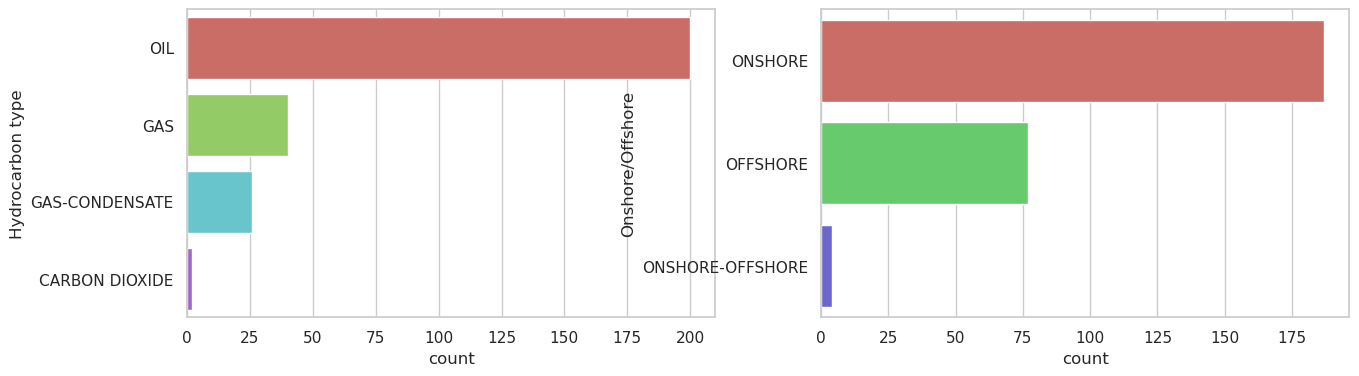

In [27]:
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

fig, ax = plt.subplots(1,2, figsize=(15, 4))

sns.countplot(y=train['Hydrocarbon type'], ax=ax[0], palette='hls', hue=train['Hydrocarbon type'], legend=False)
sns.countplot(y=train['Onshore/Offshore'], ax=ax[1], palette='hls', hue=train['Onshore/Offshore'], legend=False)
plt.show()

In [28]:
train['Onshore/Offshore'].value_counts()

Onshore/Offshore
ONSHORE             187
OFFSHORE             77
ONSHORE-OFFSHORE      4
Name: count, dtype: int64

In [29]:
test.columns

Index(['Latitude', 'Longitude', 'Hydrocarbon type', 'Reservoir status',
       'Depth', 'Reservoir period', 'Lithology',
       'Thickness (gross average ft)', 'Thickness (net pay average ft)',
       'Porosity', 'Permeability'],
      dtype='object')

Остальные категориальные признаки устроены проще и к ним можно применить обычные методы кодирования, которые мы изучали до этого.

Применим к ним кодировщик LabelEncoder().

In [30]:
from sklearn.model_selection import train_test_split

X = train.drop(columns=['Onshore/Offshore'])
y = train['Onshore/Offshore']

# Разбиваем данные с учетом стратификации
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,           # 20% данных в тест
    random_state = 42,         # Фиксируем для воспроизводимости
    stratify = y               # Стратифицированное разбиение
)

print(f'Train dataset size: {X_train.shape}, {y_train.shape}')
print(f'Train dataset size: {X_test.shape}, {y_test.shape}')

Train dataset size: (214, 11), (214,)
Train dataset size: (54, 11), (54,)


In [31]:
from sklearn.preprocessing import OrdinalEncoder

# Список категориальных столбцов
categ = ['Hydrocarbon type', 'Reservoir status', 'Reservoir period', 'Lithology']

# Создаем OrdinalEncoder, обрабатываем неизвестные категории специальным значением -1
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

train_encoded = encoder.fit_transform(X_train[categ]) # numpy
test_encoded = encoder.transform(X_test[categ]) # numpy

# Заменяем старые категориальные столбцы новыми закодированными
X_train[categ] = train_encoded
X_test[categ] = test_encoded

In [32]:
X_train.head(10).T

,248,48,303,288,287,10,200,138,75,304
Latitude,70.3400,55.2197,32.1270,5.6284,23.5310,9.8228,47.9903,33.1875,52.8381,-6.0136
Longitude,-149.5375,-119.1749,-102.6353,114.8906,53.2953,-70.9198,2.9619,-97.9167,51.2136,142.8409
Hydrocarbon type,3.0000,3.0000,3.0000,3.0000,3.0000,3.0000,3.0000,1.0000,3.0000,2.0000
Reservoir status,2.0000,2.0000,6.0000,2.0000,9.0000,8.0000,6.0000,5.0000,6.0000,1.0000
Depth,5620.0000,6125.0000,4185.0000,1180.0000,7650.0000,1104.0000,1860.0000,4500.0000,5266.0000,9905.0000
Reservoir period,3.0000,18.0000,16.0000,11.0000,3.0000,11.0000,3.0000,1.0000,1.0000,9.0000
Lithology,6.0000,7.0000,3.0000,7.0000,5.0000,11.0000,7.0000,2.0000,7.0000,7.0000
Thickness (gross average ft),35.0000,80.0000,350.0000,6739.0000,420.0000,1400.0000,28.0000,1100.0000,70.0000,490.0000
Thickness (net pay average ft),20.0000,22.0000,40.0000,500.0000,290.0000,100.0000,15.0000,73.0000,46.0000,240.0000
Porosity,24.0000,10.2000,8.0000,23.0000,23.0000,30.0000,27.0000,10.0000,20.0000,10.0000


In [33]:
y_train

248     ONSHORE
48      ONSHORE
303     ONSHORE
288    OFFSHORE
287     ONSHORE
         ...   
154     ONSHORE
211     ONSHORE
187     ONSHORE
244     ONSHORE
65      ONSHORE
Name: Onshore/Offshore, Length: 214, dtype: object

In [34]:
y_train.value_counts()

Onshore/Offshore
ONSHORE             149
OFFSHORE             62
ONSHORE-OFFSHORE      3
Name: count, dtype: int64

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

y_train

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 2,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

Heatmap позволяет визуадизировать матрицу корреляции между данными.

Корреляция - важнейший фактор, лежащий в основе анализа данных. Он сообщает, как переменные в наборе данных связаны друг с другом и как они перемещаются относительно друг друга. Значение корреляции колеблется от -1 до +1. 0 Корреляция означает, что две переменные не зависят друг от друга. Положительная корреляция указывает на то, что переменные движутся в одном направлении, а отрицательная корреляция указывает на противоположное.

In [36]:
tmp = pd.concat([X_train.reset_index(), pd.DataFrame(y_train)], axis=1)

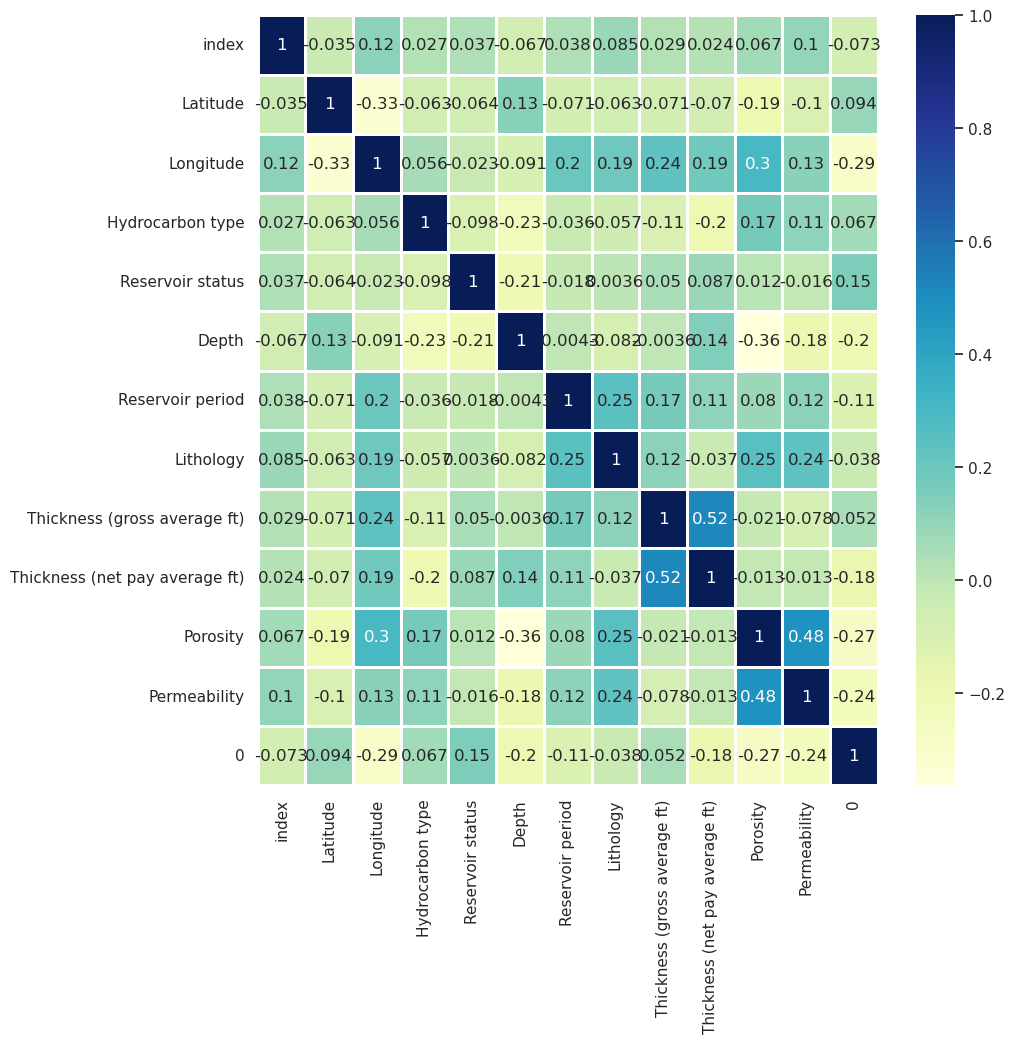

In [37]:
sns.set(rc = {'figure.figsize':(10, 10)})

sns.heatmap(tmp.corr(), annot = True, cmap="YlGnBu", linecolor='white',linewidths=1)

plt.savefig("heatmap.png")

In [38]:
train.corr(numeric_only=True)

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
Latitude,1.000000,-0.323678,0.133160,-0.065420,-0.056571,-0.181211,-0.147912
Longitude,-0.323678,1.000000,-0.100164,0.217488,0.162770,0.270450,0.150411
Depth,0.133160,-0.100164,1.000000,0.018561,0.174854,-0.380279,-0.216259
Thickness (gross average ft),-0.065420,0.217488,0.018561,1.000000,0.501022,-0.037438,-0.091668
Thickness (net pay average ft),-0.056571,0.162770,0.174854,0.501022,1.000000,-0.061748,-0.051282
Porosity,-0.181211,0.270450,-0.380279,-0.037438,-0.061748,1.000000,0.484160
Permeability,-0.147912,0.150411,-0.216259,-0.091668,-0.051282,0.484160,1.000000


По сути, это сетка цветных квадратов , где каждый квадрат, или bin , отмечает пересечение значений двух переменных, которые простираются вдоль горизонтальной и вертикальной осей.

Цветовые палитры: https://seaborn.pydata.org/tutorial/color_palettes.html

Информация о HeatMap: https://seaborn.pydata.org/generated/seaborn.heatmap.html


In [39]:
# train_X.columns
# test_X.columns

# len(set(train_X.columns) & set(test_X.columns)) == len(train_X.columns)

In [40]:
# sns.set()
# columns = ['Onshore/Offshore', 'Reservoir status', 'Depth', 'Lithology_CHALK', 'Reservoir period_CRETACEOUS-PALEOGENE',
#            'Thickness (gross average ft)', 'Thickness (net pay average ft)', 'Porosity', 'Permeability', 'Region', 'Latitude', 'Longitude']

# sns.pairplot(train[columns], size = 4, kind ='scatter', diag_kind='kde')
# plt.show()

# plt.savefig("pairplot.png")

In [41]:
# sns.set()
# columns = ['Region', 'Latitude', 'Longitude']

# sns.pairplot(train[columns], kind ='scatter', diag_kind='kde')
# plt.show()

In [42]:
# sns.set()
# columns = ['Reservoir period_MESOZOIC', 'Lithology_VOLCANICS']

# sns.pairplot(train[columns], kind ='scatter', diag_kind='kde')
# plt.show()

Посмотрим на баланс классов.

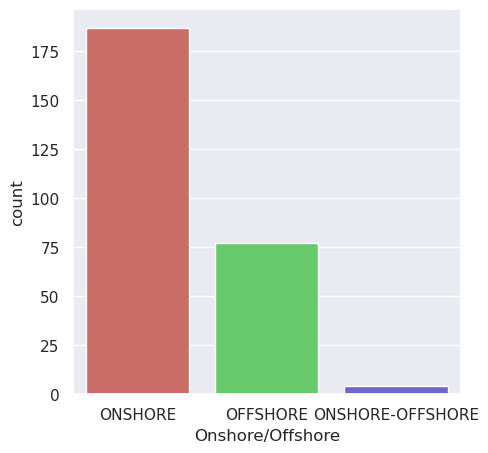

In [43]:
sns.set(rc = {'figure.figsize':(5,5)})
y_data = pd.DataFrame(train['Onshore/Offshore'])
sns.countplot(x='Onshore/Offshore', data=y_data, palette='hls', hue='Onshore/Offshore')
plt.show()

In [44]:
train['Onshore/Offshore'].value_counts()

Onshore/Offshore
ONSHORE             187
OFFSHORE             77
ONSHORE-OFFSHORE      4
Name: count, dtype: int64

In [45]:
train.head()

,Latitude,Longitude,Onshore/Offshore,Hydrocarbon type,Reservoir status,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,51.0000,44.8042,ONSHORE,OIL,DECLINING PRODUCTION,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,-19.6017,-39.8332,ONSHORE,OIL,NEARLY DEPLETED,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,26.0800,49.8100,ONSHORE,OIL,REJUVENATING,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,61.3833,1.7500,OFFSHORE,OIL,NEARLY DEPLETED,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,53.2287,-115.8008,ONSHORE,OIL,UNKNOWN,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


In [46]:
train.columns

Index(['Latitude', 'Longitude', 'Onshore/Offshore', 'Hydrocarbon type',
       'Reservoir status', 'Depth', 'Reservoir period', 'Lithology',
       'Thickness (gross average ft)', 'Thickness (net pay average ft)',
       'Porosity', 'Permeability'],
      dtype='object')

In [47]:
# train = train.drop(columns=['Field name','Reservoir unit', 'Country','Basin name', 'Operator company'])

In [48]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 268 entries, 0 to 308
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Latitude                        268 non-null    float64
 1   Longitude                       268 non-null    float64
 2   Onshore/Offshore                268 non-null    object 
 3   Hydrocarbon type                268 non-null    object 
 4   Reservoir status                268 non-null    object 
 5   Depth                           268 non-null    int64  
 6   Reservoir period                268 non-null    object 
 7   Lithology                       268 non-null    object 
 8   Thickness (gross average ft)    268 non-null    float64
 9   Thickness (net pay average ft)  268 non-null    float64
 10  Porosity                        268 non-null    float64
 11  Permeability                    268 non-null    float64
dtypes: float64(6), int64(1), object(5)
memory

## Обучение модели

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Создадим модель дерева решений
tree = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(2)

# обучение модели
tree.fit(X_train, y_train)
knn.fit(X_train, y_train)

# предсказание ответов для тестовой выборки
y_pred_tree = tree.predict(X_test)
y_pred_knn = knn.predict(X_test)

In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# answers_pred - ответы которые вернула модель для X_test
# y_test - это правильные ответы для X_test
print(f'Accuracy: {accuracy_score(y_test, y_pred_tree)}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_knn)}')

Accuracy: 0.8148148148148148
Accuracy: 0.6111111111111112


In [51]:
import numpy as np

np.unique(y_train)

array([0, 1, 2])

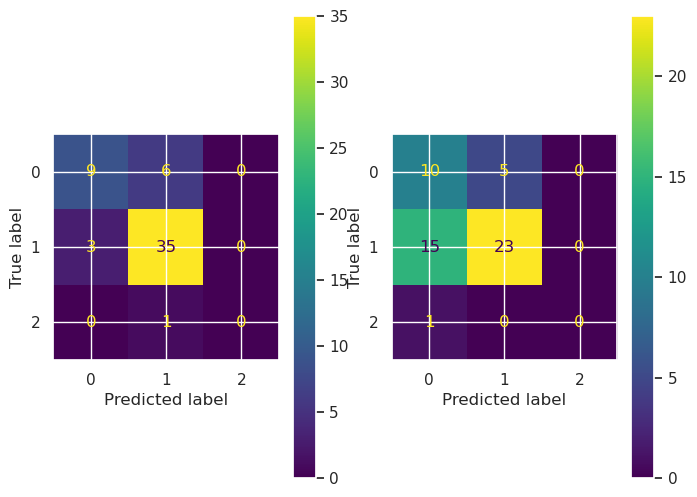

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(8,6), dpi=100)

display = ConfusionMatrixDisplay(conf_matrix_tree, display_labels=tree.classes_)
display.plot(ax=axes[0])

display = ConfusionMatrixDisplay(conf_matrix_knn, display_labels=knn.classes_)
display.plot(ax=axes[1])

# Финальный сабмит

In [53]:
train.shape

(268, 12)

In [54]:
test.shape

(133, 11)

In [55]:
train = train.dropna()

In [56]:
train.shape

(268, 12)

In [57]:
test['Latitude'] = test['Latitude'].fillna(0)
test['Longitude'] = test['Longitude'].fillna(0)

In [58]:
from sklearn.preprocessing import OrdinalEncoder

# Список категориальных столбцов
categ = ['Hydrocarbon type', 'Reservoir status', 'Reservoir period', 'Lithology']

# Создаем OrdinalEncoder, обрабатываем неизвестные категории специальным значением -1
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

train_encoded = encoder.fit_transform(train[categ]) # numpy
test_encoded = encoder.transform(test[categ]) # numpy

# Заменяем старые категориальные столбцы новыми закодированными
train[categ] = train_encoded
test[categ] = test_encoded

In [59]:
from sklearn.tree import DecisionTreeClassifier

# Создадим модель дерева решений
tree = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier(2)

X = train.drop(columns=['Onshore/Offshore'])
y = train['Onshore/Offshore']
y = le.fit_transform(y)

# обучение модели
tree.fit(X, y)

# предсказание ответов для тестовой выборки
y_pred_tree = tree.predict(test)

In [60]:
y_pred_tree

array([1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 2, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1,
       1])

In [61]:
y_pred_tree.sum()

np.int64(99)

In [62]:
ans_df = pd.DataFrame(y_pred_tree, columns=['Onshore/Offshore'])

ans_df.reset_index(inplace=True)
ans_df.to_csv('./classification-of-oil-and-gas/submition_baseline.csv', index=False)